# Phase 3 — Cleveland Corral exploratory dynamics

This restart-and-run notebook explains and inspects the reproducible Phase 3 build. It uses only Phase 2 quality-flagged, explicitly segmented records; fixed PST remains UTC−08:00 year-round. It does **not** interpolate, splice successors, forecast, fit ARIMA/ARIMAX models, detect changepoints, or make causal claims.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = Path.cwd().parent
assert (PROJECT_ROOT / 'pyproject.toml').is_file(), 'Run this notebook inside the project.'
TABLES = PROJECT_ROOT / 'reports/tables/phase3'
FIGURES = PROJECT_ROOT / 'reports/figures/phase3'
PROCESSED = PROJECT_ROOT / 'data/processed/cleveland_corral'
print('Project root located; all paths below are repository-relative.')

Project root located; all paths below are repository-relative.


## Reproduce or verify

A fresh local restart has no ignored processed outputs, so the cell below runs the complete Phase 3 build. When verified processed outputs already exist, it validates and reuses them so repeated notebook execution is fast. Set `FORCE_PHASE3_REBUILD=1` to force a complete rebuild.

In [2]:
daily_output = PROCESSED / 'phase3_daily_analysis_series.parquet'
force_rebuild = os.environ.get('FORCE_PHASE3_REBUILD') == '1'
if force_rebuild or not daily_output.is_file():
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / 'scripts/build_phase3_analysis.py')],
        cwd=PROJECT_ROOT,
        check=True,
    )
else:
    print('Reusing existing ignored processed outputs; set FORCE_PHASE3_REBUILD=1 to rebuild.')
subprocess.run(
    [sys.executable, str(PROJECT_ROOT / 'scripts/verify_phase3_outputs.py')],
    cwd=PROJECT_ROOT,
    check=True,
)

Reusing existing ignored processed outputs; set FORCE_PHASE3_REBUILD=1 to rebuild.


CompletedProcess(args=['C:\\Users\\ddtam\\OneDrive\\Documents\\ChatGPT\\GEOTECH TIME SERIES PROJECT\\.venv\\Scripts\\python.exe', 'C:\\Users\\ddtam\\OneDrive\\Documents\\ChatGPT\\GEOTECH TIME SERIES PROJECT\\scripts\\verify_phase3_outputs.py'], returncode=0)

## Masks and transformations

Levels require a numeric timestamped observation inside documented operation and outside fatal QC or maintenance flags. Metadata range concerns remain eligible and visible. Changes use consecutive dates inside one installation segment; cumulative displacement also stays inside one water year. Rain is defined two ways: valid within-water-year differences of the published cumulative daily field, and sums of at least 90 eligible 15-minute interval-rain values.

In [3]:
configuration = pd.read_csv(TABLES / 'analysis_configuration.csv')
display(configuration)

,parameter,value
0,time_zone,fixed PST (UTC-08:00) year-round
1,daily_alignment,exact local date; no interpolation
2,level_mask,numeric timestamped rows inside documented ope...
3,metadata_range_concerns,retained and counted; not automatically invali...
4,daily_interval_rain_minimum_coverage,90 of 96 nominal 15-minute intervals
5,published_rain_difference,"consecutive eligible dates, same water year an..."
6,displacement_difference,"consecutive eligible dates, same water year an..."
7,decomposition,robust STL on exact contiguous daily runs; per...
8,stationarity,ADF with intercept/AIC lags plus KPSS level-st...
9,acf_pacf,"daily lags, maximum 60 or sample-size limit; a..."


## Coverage, missingness, and regimes

A blank measurement is a published station row with no sensor value. An absent timestamp is a missing expected row inside a segment span. They have different implications and are never converted to zero.

,sensor_id,installation_segment_id,absent_timestamp_count,blank_measurement_count,eligible_level_count,range_concern_retained_count
24,mid_E2_B,mid_E2_B_s01_hx_pa_400_29030259,0,10,1128,28
25,mid_E2_B,mid_E2_B_s02_hx_vpa_400_27090342,0,21,538,5
26,mid_E2_B,mid_E2_B_s03_hx_pa_400_29030259,0,6,207,21
27,mid_E2_B,mid_E2_B_s04_hx_vpa_400_27090342,0,6,98,0
28,mid_E2_B,mid_E2_B_s05_hx_pa_400_29030259,0,1,293,154
29,mid_E2_B,mid_E2_B_s06_hx_vpa_400_27090342,0,121,2545,590
30,mid_E2_B,mid_E2_B_s07_hx_pa_400_39070751,0,30,817,20
31,mid_P1,mid_P1_s01_usgs5_depth_1_79m,83,129,2909,1201
32,mid_P1,mid_P1_s02_usgsct2_depth_1_82m,0,65,4463,2562
33,mid_P1,outside_documented_operation,0,7,0,0


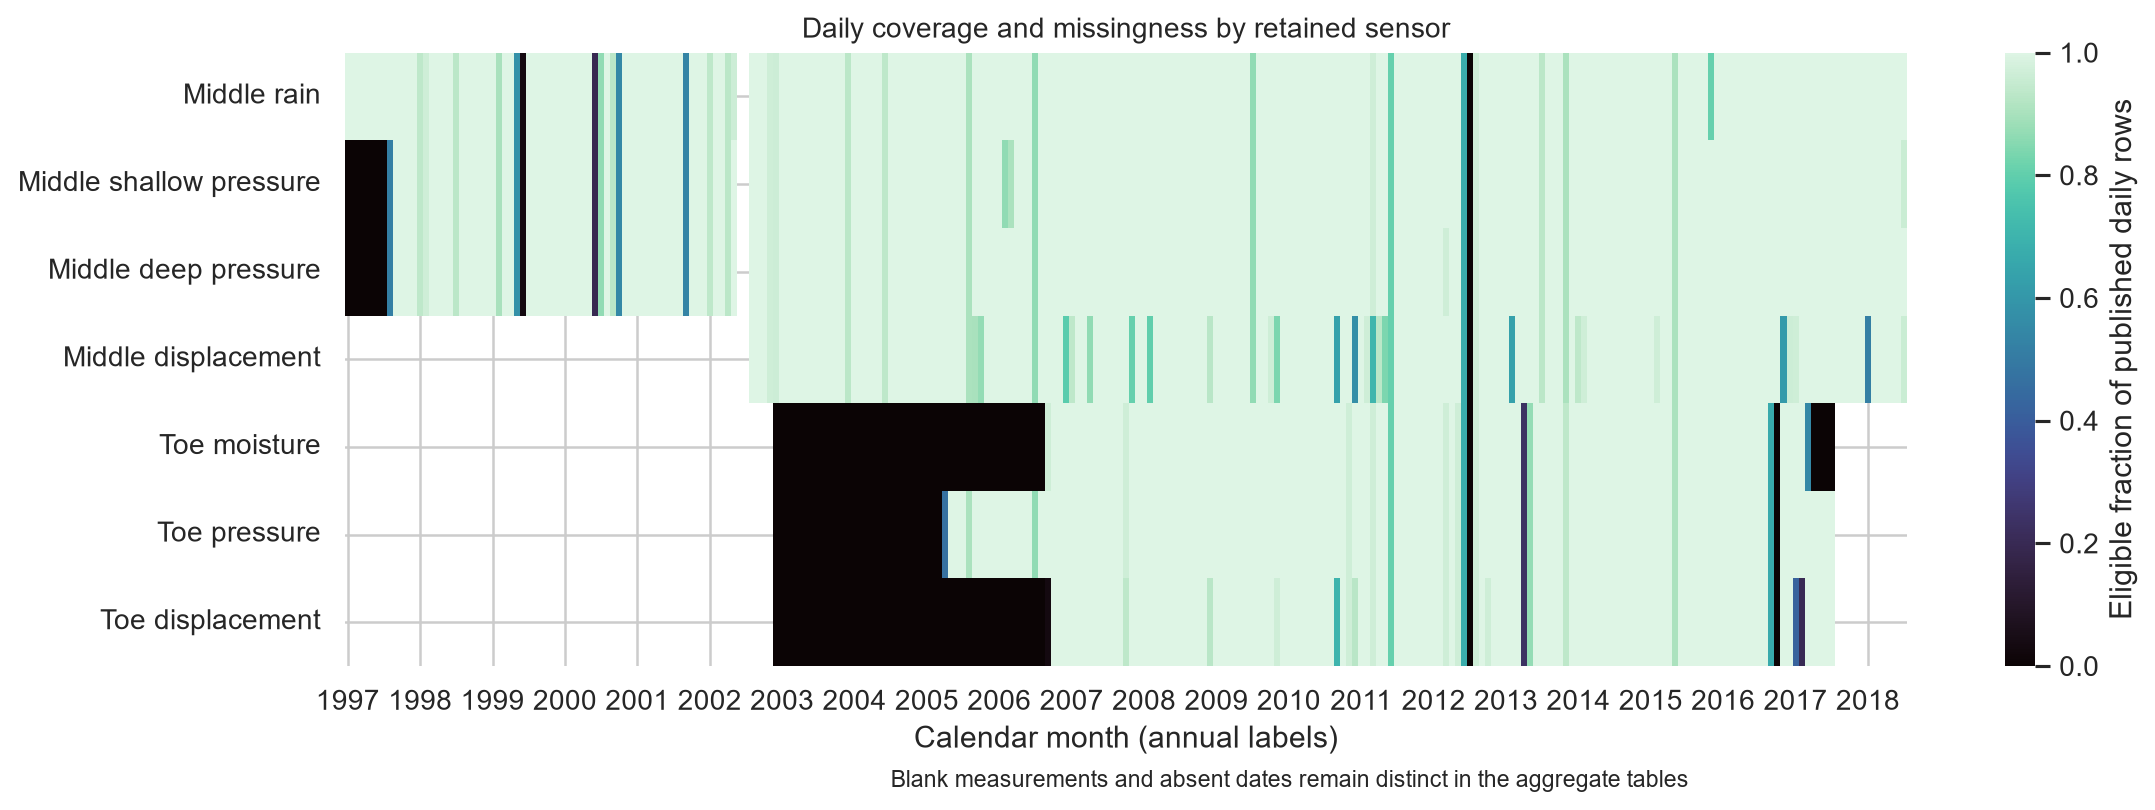

In [4]:
coverage = pd.read_csv(TABLES / 'coverage_missingness.csv')
display(
    coverage.loc[
        coverage['product_type'].eq('daily'),
        ['sensor_id', 'installation_segment_id', 'absent_timestamp_count',
         'blank_measurement_count', 'eligible_level_count',
         'range_concern_retained_count'],
    ]
)
display(Image(filename=str(FIGURES / '01_daily_coverage_missingness.png')))

## Trend, seasonality, and stationarity

STL is used only on exact contiguous daily runs at least two annual cycles long, with 365 days selected and 366 days checked. ADF tests a unit-root null; KPSS tests a level-stationarity null. Agreement is more informative than either test alone, while seasonality and structural behavior still limit both.

,sensor_id,transformation,joint_interpretation,run_count
0,mid_E2_B,daily_first_difference,consistent_with_level_stationarity,4
1,mid_E2_B,daily_first_difference,tests_disagree_or_are_inconclusive,1
2,mid_E2_B,daily_level,consistent_with_level_stationarity,1
3,mid_E2_B,daily_level,consistent_with_nonstationarity,15
4,mid_E2_B,daily_level,tests_disagree_or_are_inconclusive,1
5,mid_P1,daily_first_difference,consistent_with_level_stationarity,2
6,mid_P1,daily_level,consistent_with_nonstationarity,1
7,mid_P1,daily_level,tests_disagree_or_are_inconclusive,1
8,mid_P2,daily_first_difference,consistent_with_level_stationarity,1
9,mid_P2,daily_level,tests_disagree_or_are_inconclusive,1


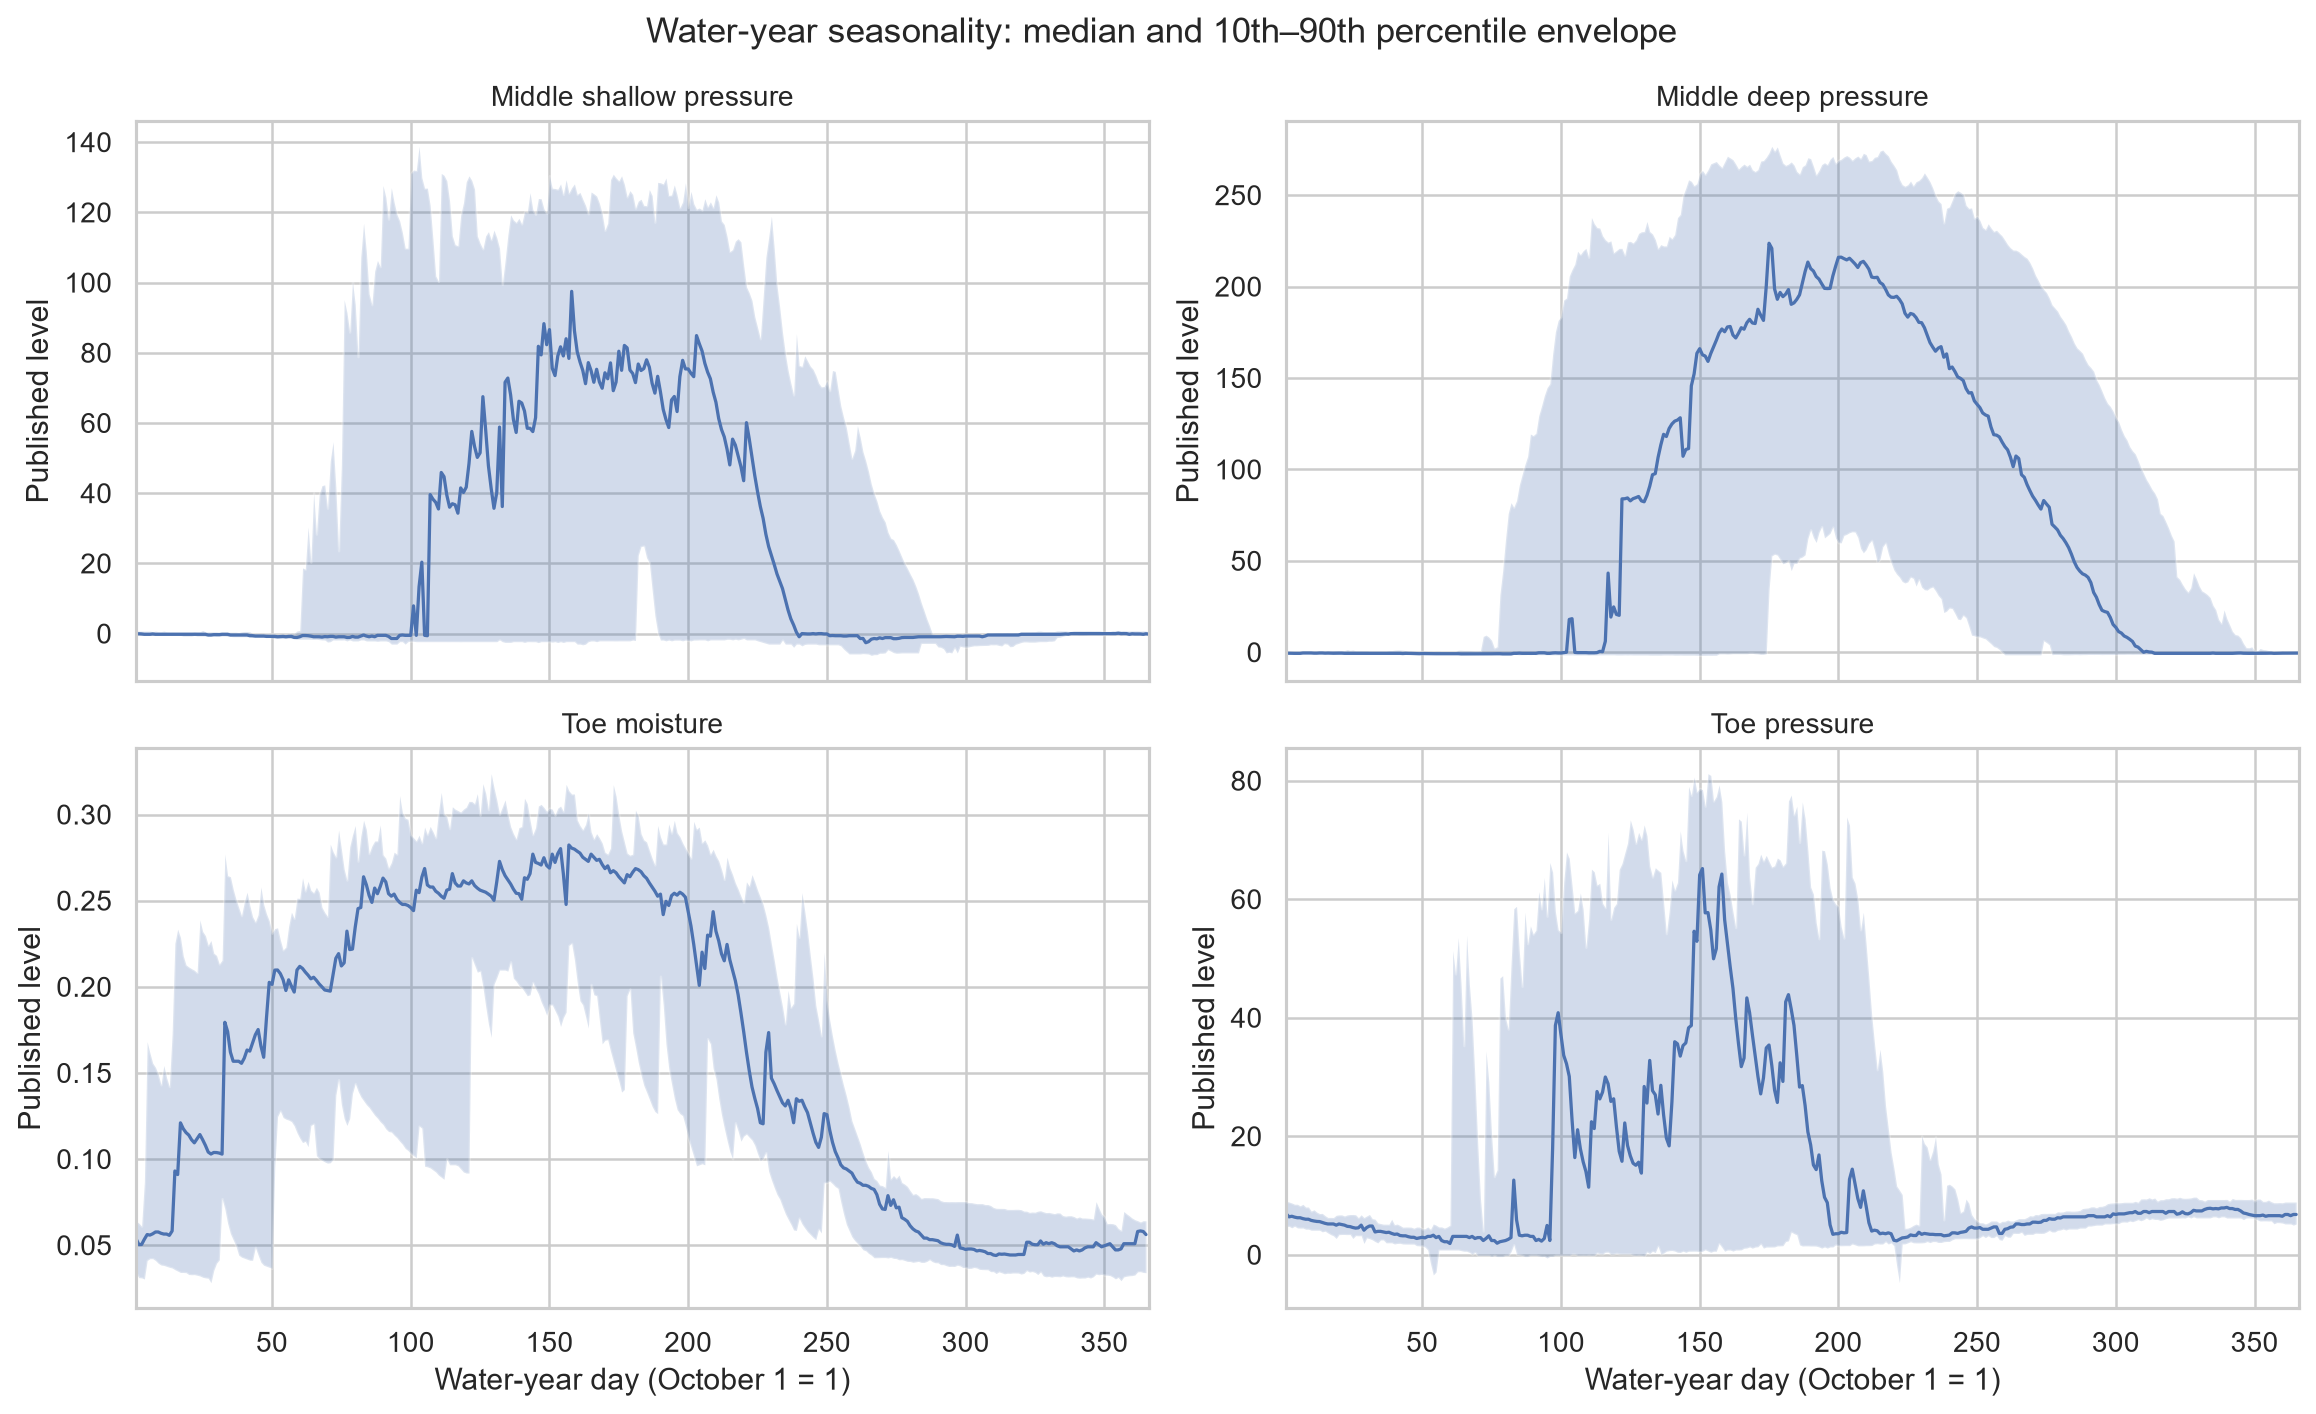

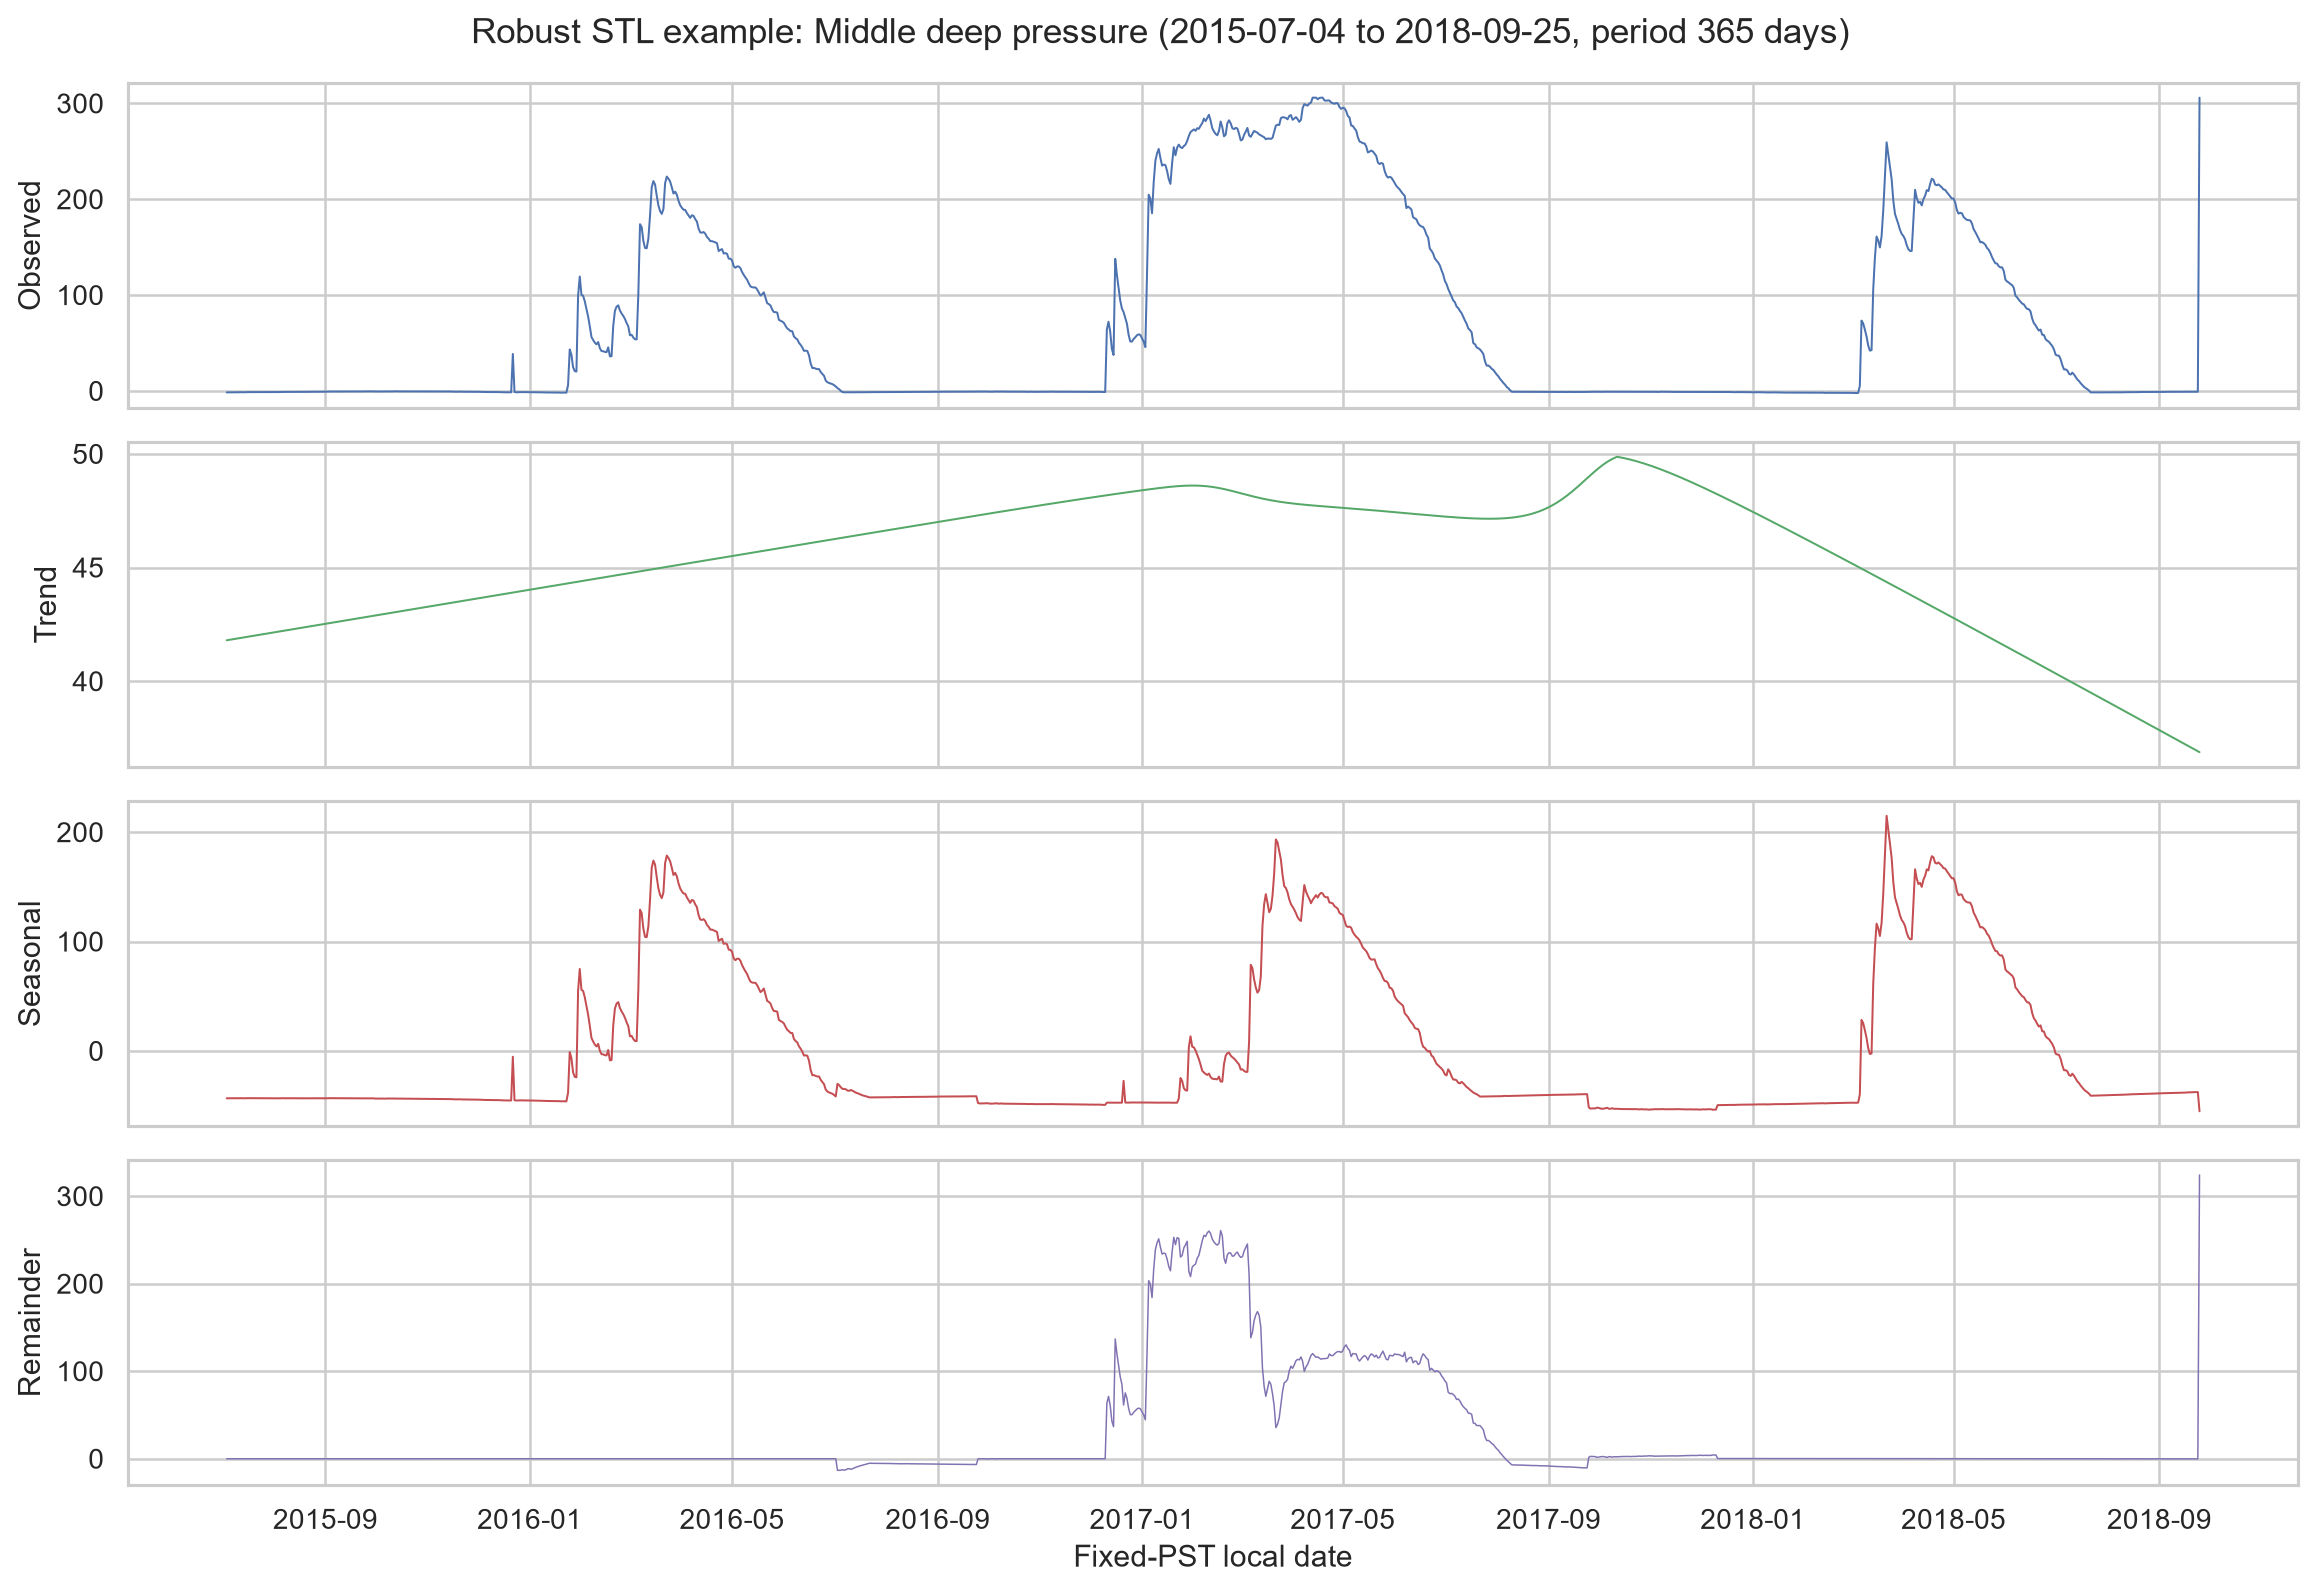

In [5]:
stationarity = pd.read_csv(TABLES / 'stationarity_diagnostics.csv')
summary = (
    stationarity.groupby(['sensor_id', 'transformation', 'joint_interpretation'])
    .size()
    .rename('run_count')
    .reset_index()
)
display(summary)
display(Image(filename=str(FIGURES / '04_water_year_seasonality.png')))
display(Image(filename=str(FIGURES / '05_robust_stl_decomposition.png')))

## ACF and PACF

ACF measures correlation between a series and lagged copies. PACF measures the additional association at a lag after accounting for shorter lags. The confidence bands here are approximate; autocorrelation, seasonality, and finite samples complicate their interpretation. The synthetic demonstration uses seed 170 and is never mixed with USGS observations.

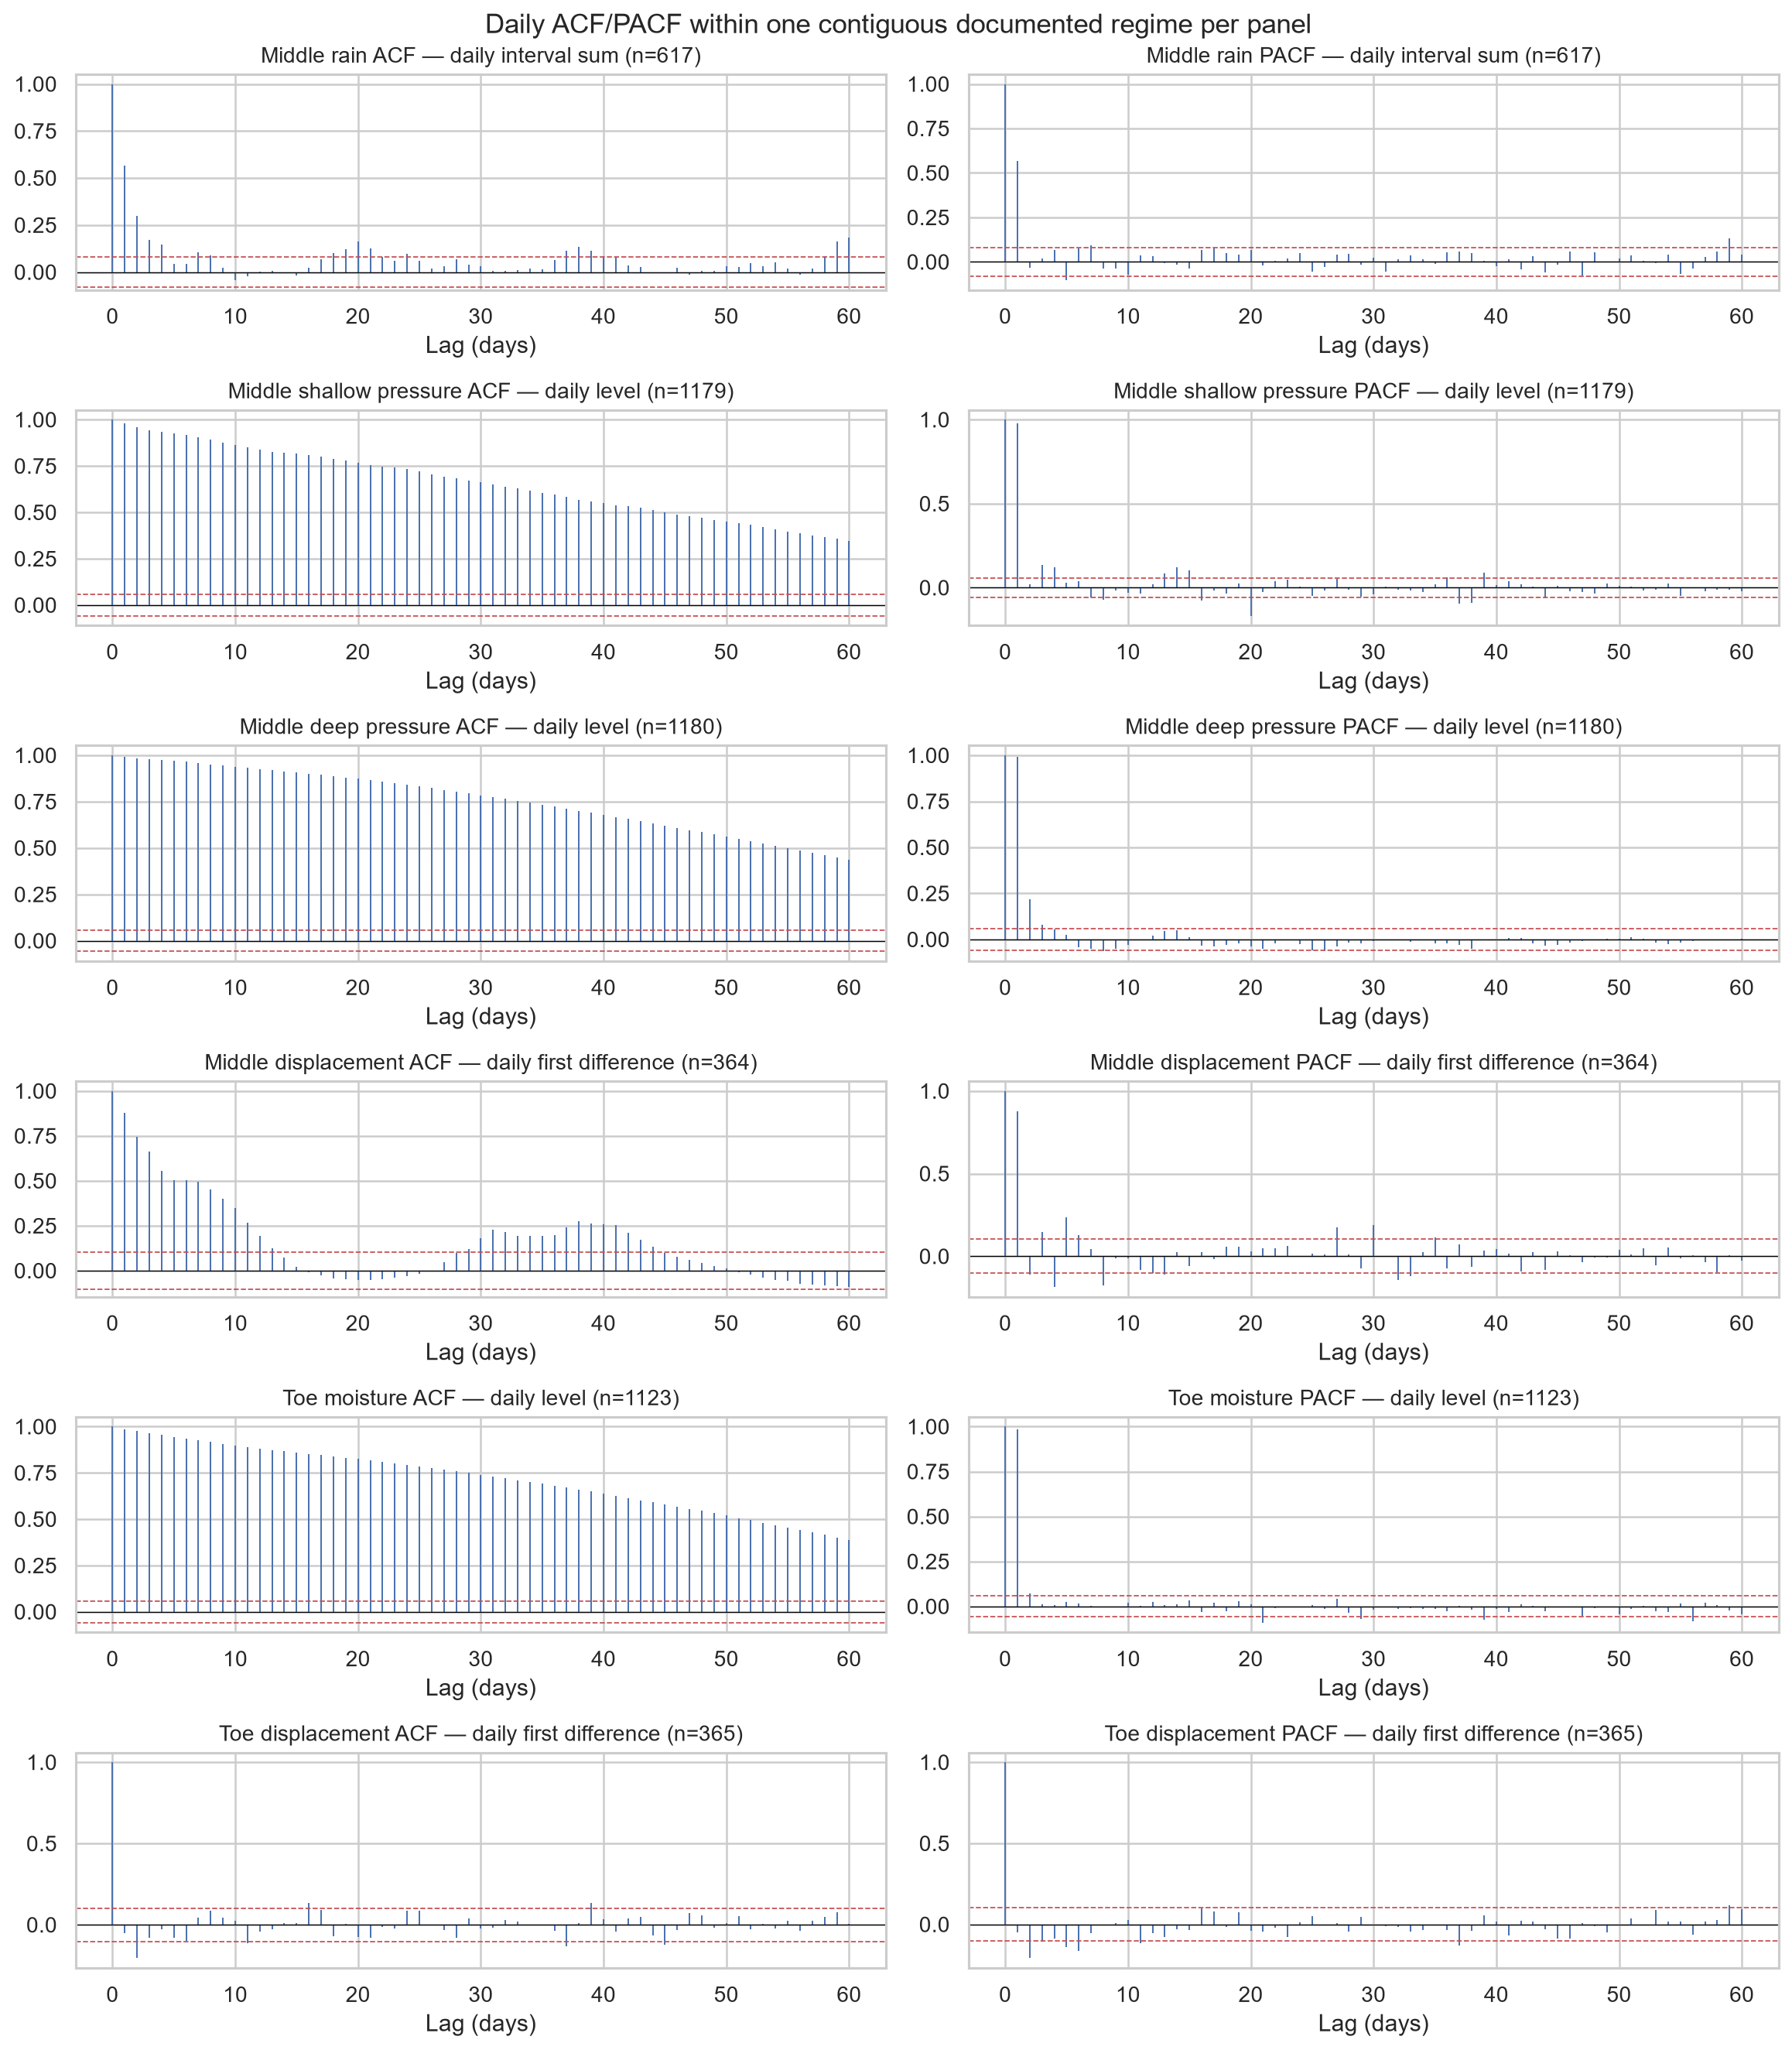

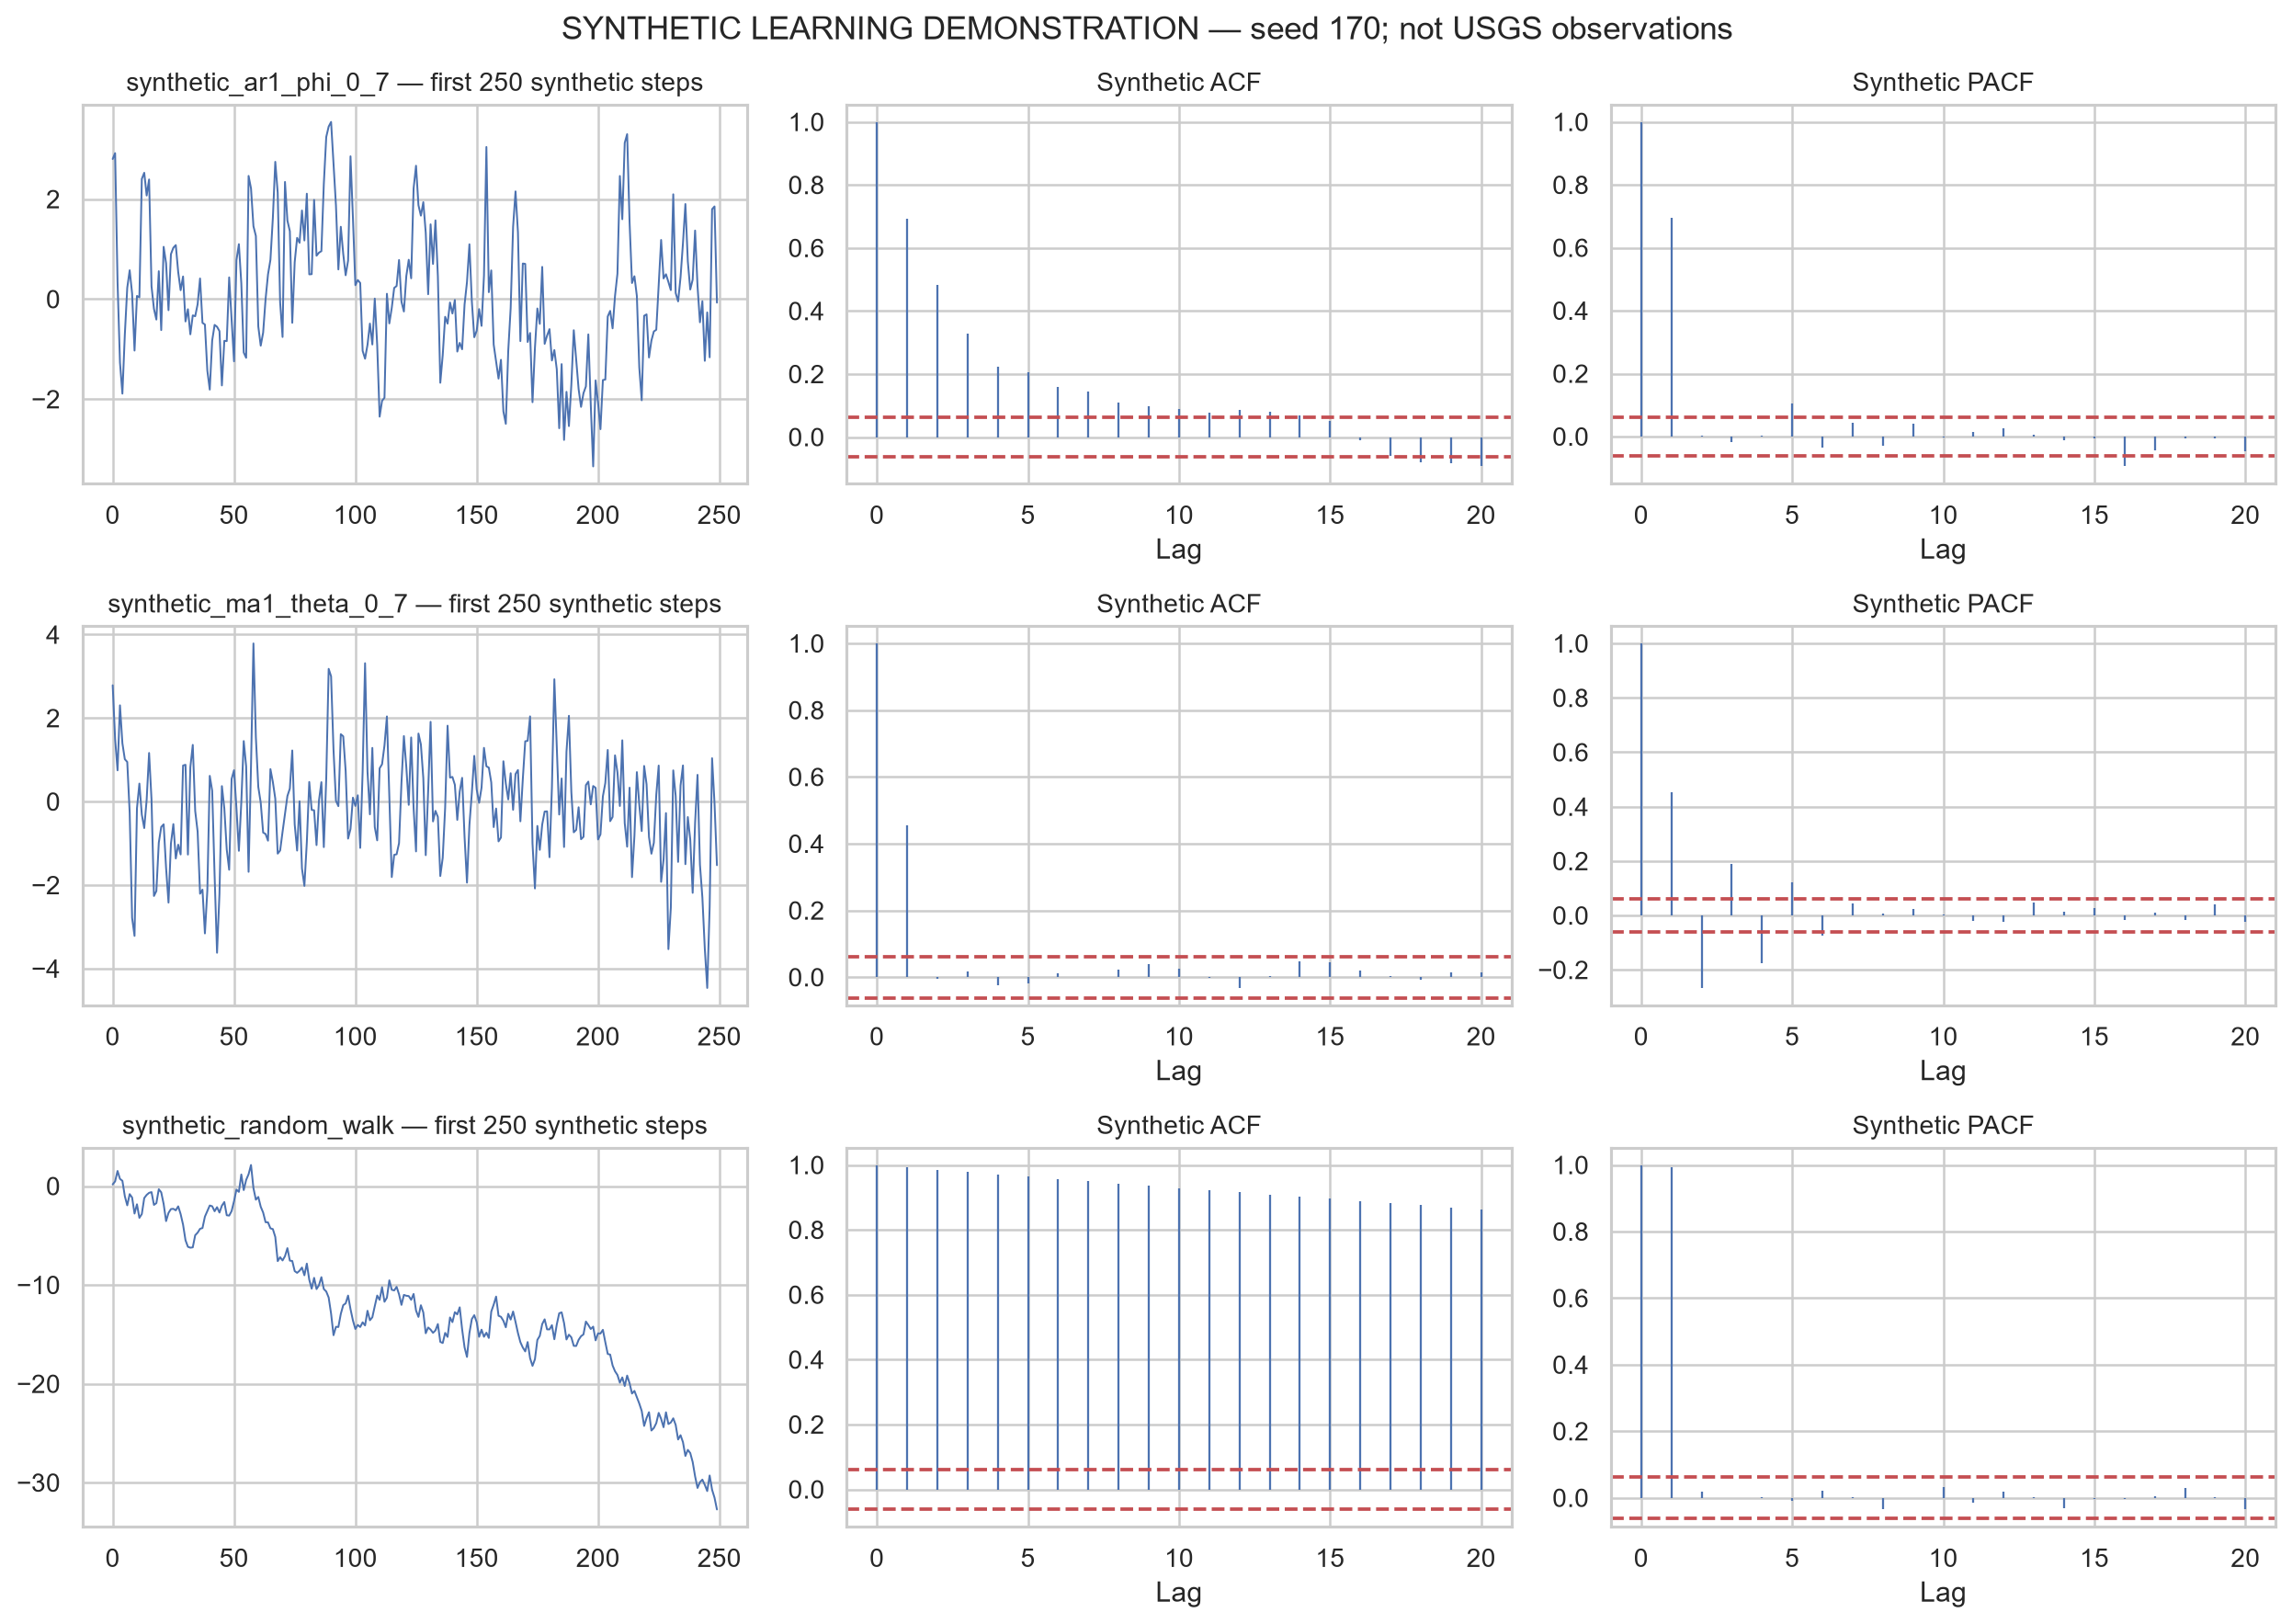

In [6]:
display(Image(filename=str(FIGURES / '06_daily_acf_pacf.png')))
display(Image(filename=str(FIGURES / '09_synthetic_linear_processes.png')))

## Exact-date daily lag associations

**Positive lag means the predictor leads the response.** The declared search is 0–30 days. Naive level correlations are compared with valid changes and cautious predictor-AR(1) prewhitening. This is essential because shared trend, seasonality, and autocorrelation can create apparently strong cross-correlations without a physical lag.

,window_id,predictor,response,method,rain_definition,peak_lag_days,peak_correlation,peak_pair_count,conditional_peak_correlation_ci_low,conditional_peak_correlation_ci_high
1,middle_stable_2009_2016,mid_R,mid_P1,transformed,cumulative_daily_difference,1,0.339884,2434,0.245379,0.423767
2,middle_stable_2009_2016,mid_R,mid_P1,transformed,15_minute_interval_sum,1,0.318759,2427,0.227661,0.394067
3,middle_stable_2009_2016,mid_R,mid_P1,prewhitened,cumulative_daily_difference,1,0.286218,2422,0.151520,0.390017
4,middle_stable_2009_2016,mid_R,mid_P1,prewhitened,15_minute_interval_sum,1,0.272783,2398,0.142896,0.372780
6,middle_stable_2009_2016,mid_R,mid_P2,transformed,cumulative_daily_difference,1,0.224380,2432,0.120205,0.310856
7,middle_stable_2009_2016,mid_R,mid_P2,transformed,15_minute_interval_sum,1,0.226815,2425,0.123691,0.306727
8,middle_stable_2009_2016,mid_R,mid_P2,prewhitened,cumulative_daily_difference,1,0.167151,2419,0.061763,0.244205
9,middle_stable_2009_2016,mid_R,mid_P2,prewhitened,15_minute_interval_sum,1,0.171678,2395,0.068218,0.251056
11,middle_stable_2009_2016,mid_P1,mid_E2_B,transformed,not_applicable,22,-0.023795,2323,-0.073228,0.007941
12,middle_stable_2009_2016,mid_P1,mid_E2_B,prewhitened,not_applicable,22,-0.025015,2296,-0.084462,0.005820


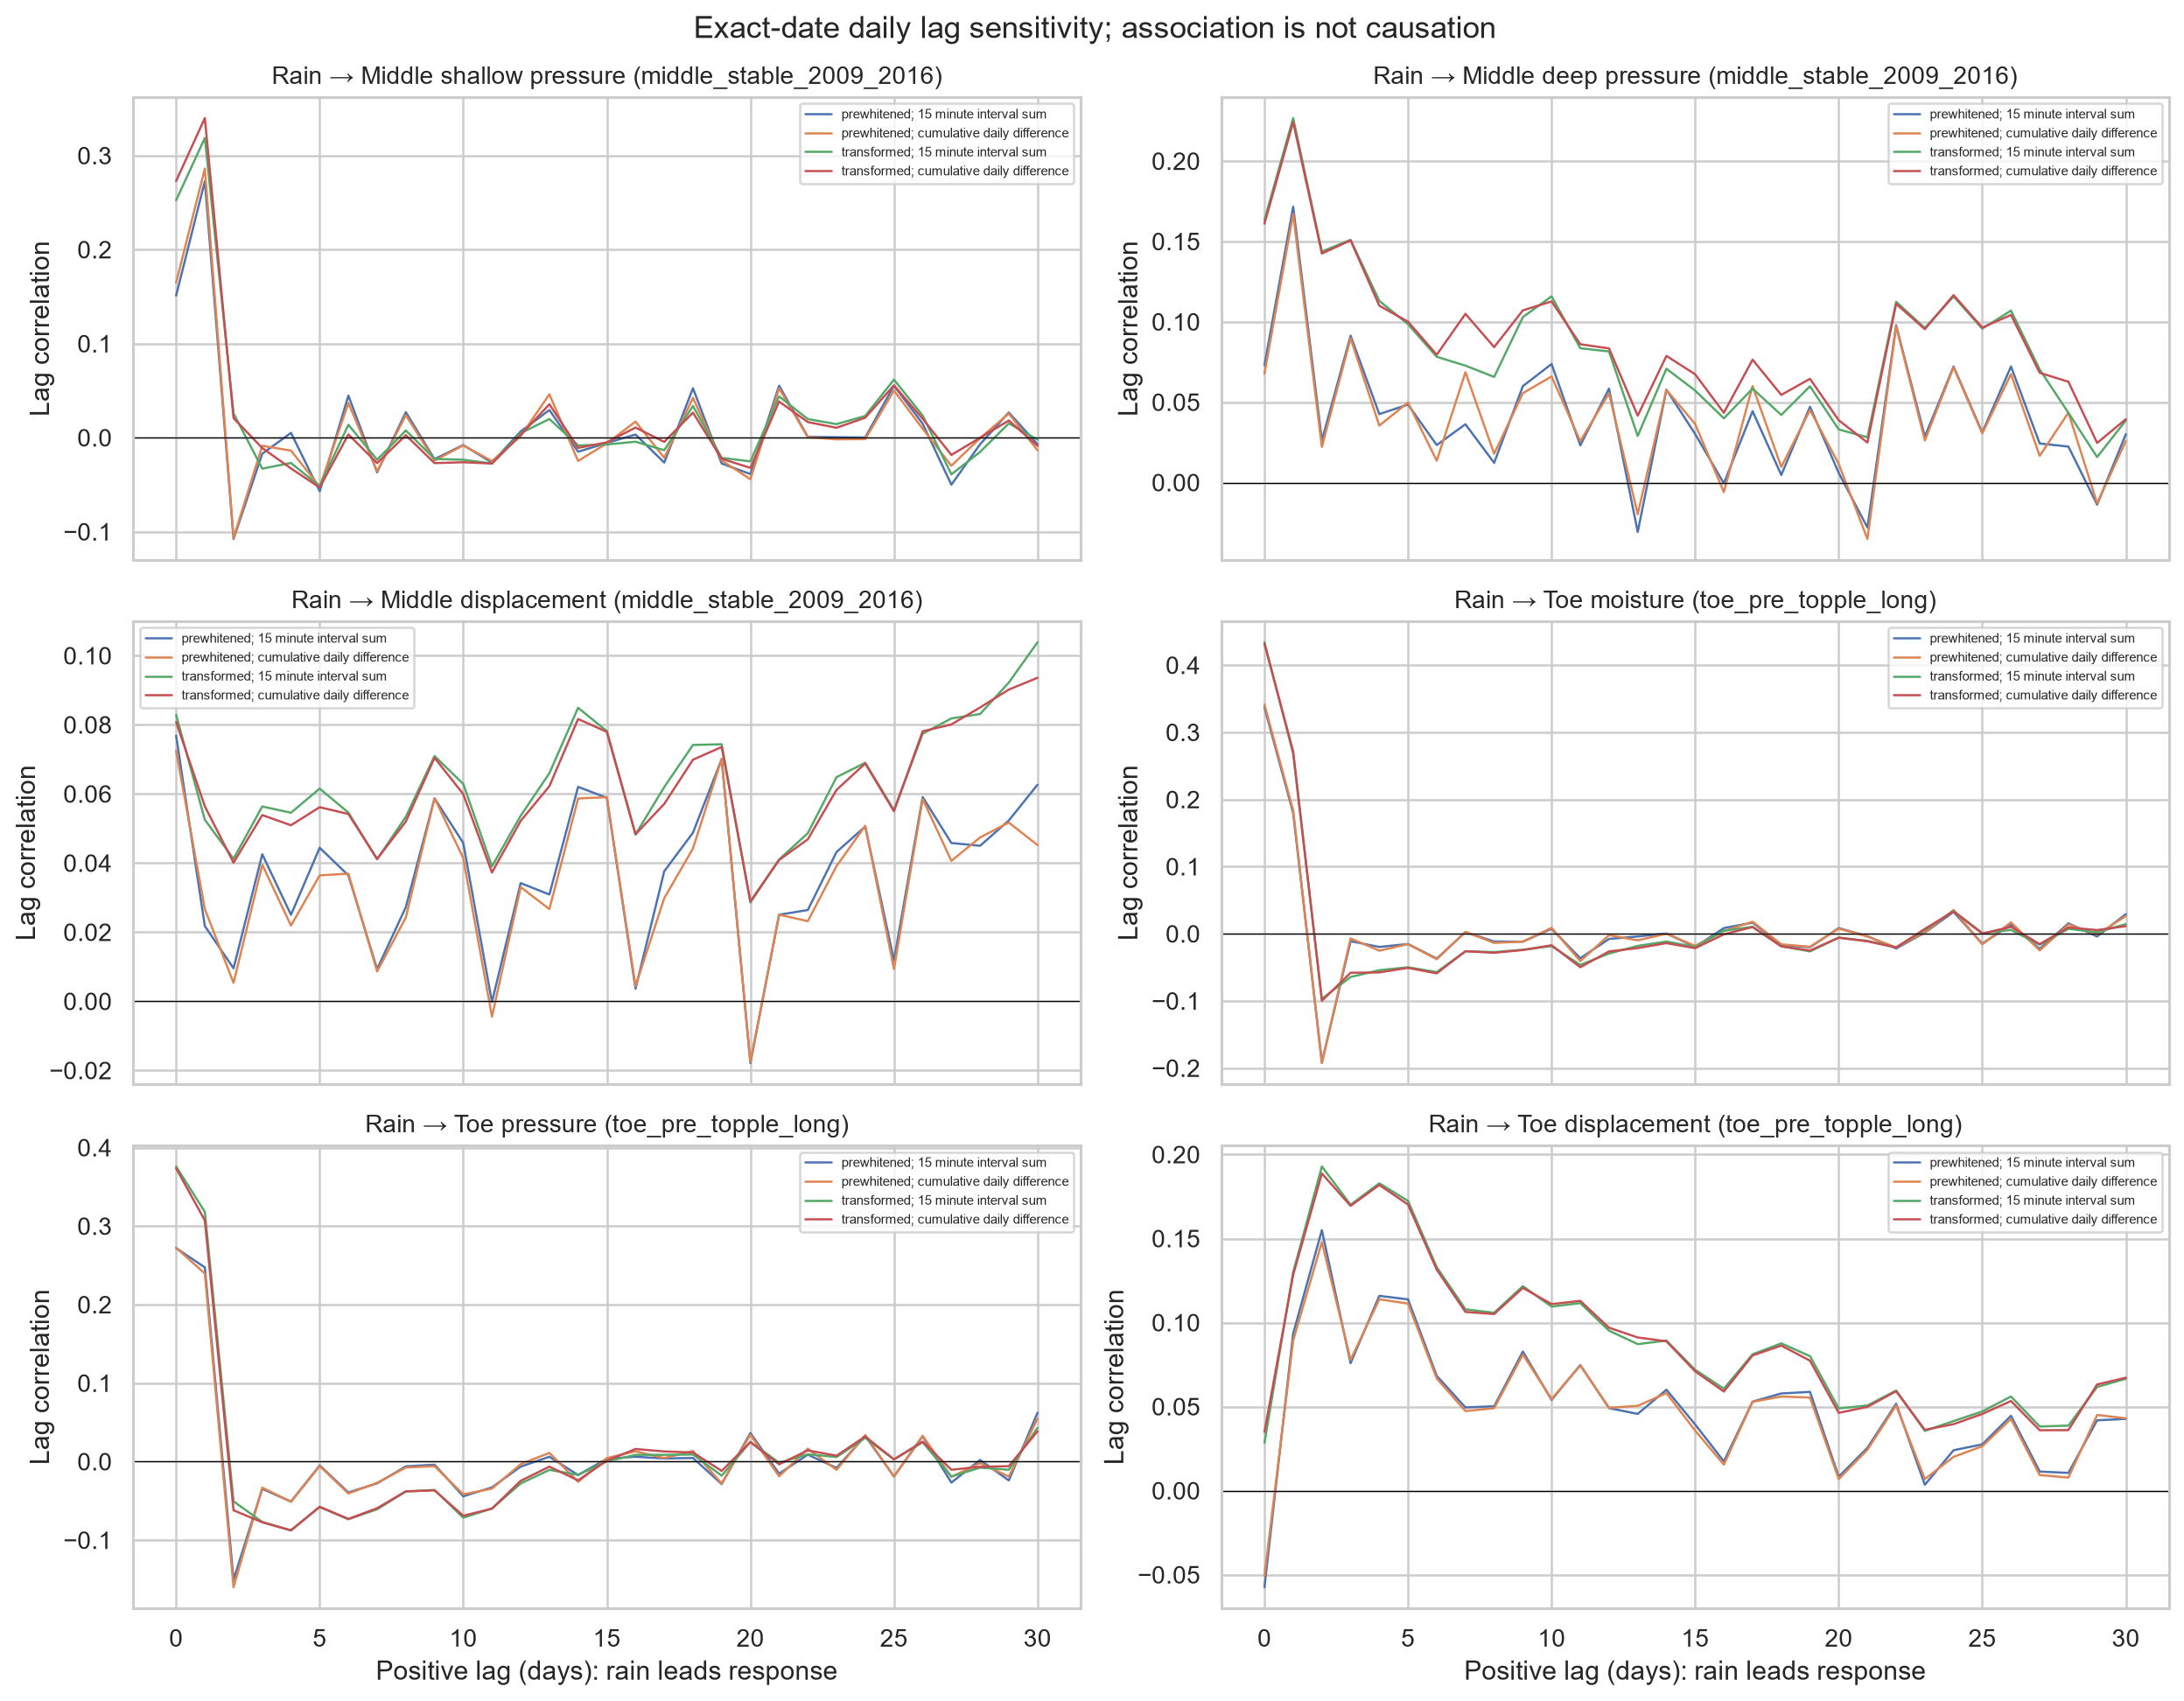

In [7]:
lags = pd.read_csv(TABLES / 'daily_lag_summary.csv')
display(
    lags.loc[
        lags['method'].isin(['transformed', 'prewhitened']),
        ['window_id', 'predictor', 'response', 'method', 'rain_definition',
         'peak_lag_days', 'peak_correlation', 'peak_pair_count',
         'conditional_peak_correlation_ci_low',
         'conditional_peak_correlation_ci_high'],
    ]
)
display(Image(filename=str(FIGURES / '07_daily_lag_sensitivity.png')))

## Rain-selected 15-minute events

Events are chosen from rain totals, never displacement outcomes. Shifted rain is matched one-to-one to response changes without reuse or interpolation. Eight- and 15-minute tolerances test clock-alignment sensitivity. Stability across tolerances does not imply stability across storms.

,event_id,selection_rank,event_date,daily_interval_rain_mm,coverage_count,selection_rule
0,rain_event_01_2010-10-24,1,2010-10-24,135.382,93,top_3_eligible_daily_interval_rain_totals_mini...
1,rain_event_02_2008-01-04,2,2008-01-04,104.140,95,top_3_eligible_daily_interval_rain_totals_mini...
2,rain_event_03_2012-11-30,3,2012-11-30,83.566,94,top_3_eligible_daily_interval_rain_totals_mini...


,event_id,event_date,daily_interval_rain_mm,response_sensor,response_transformation,alignment_rule,tolerance_minutes,event_window,lag_sign_convention,searched_lag_min_hours,searched_lag_max_hours,peak_lag_hours,peak_correlation,peak_pair_count,simultaneous_pair_count,stable_across_tolerances
0,rain_event_01_2010-10-24,2010-10-24,135.382,toe_M1_A,15_minute_first_difference,one_to_one_nearest_shifted_predictor,8.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,2.00,0.644939,107,109,False
1,rain_event_01_2010-10-24,2010-10-24,135.382,toe_M1_A,15_minute_first_difference,one_to_one_nearest_shifted_predictor,15.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,4.25,0.609369,108,109,False
2,rain_event_01_2010-10-24,2010-10-24,135.382,toe_P7_B,15_minute_first_difference,one_to_one_nearest_shifted_predictor,8.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,7.75,0.624232,106,109,True
3,rain_event_01_2010-10-24,2010-10-24,135.382,toe_P7_B,15_minute_first_difference,one_to_one_nearest_shifted_predictor,15.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,7.75,0.624232,106,109,True
4,rain_event_01_2010-10-24,2010-10-24,135.382,toe_E5_C,15_minute_first_difference,one_to_one_nearest_shifted_predictor,8.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,2.25,-0.198101,107,109,True
5,rain_event_01_2010-10-24,2010-10-24,135.382,toe_E5_C,15_minute_first_difference,one_to_one_nearest_shifted_predictor,15.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,2.25,-0.198101,107,109,True
6,rain_event_02_2008-01-04,2008-01-04,104.140,toe_M1_A,15_minute_first_difference,one_to_one_nearest_shifted_predictor,8.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,31.25,0.332794,96,178,True
7,rain_event_02_2008-01-04,2008-01-04,104.140,toe_M1_A,15_minute_first_difference,one_to_one_nearest_shifted_predictor,15.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,31.25,0.332794,96,178,True
8,rain_event_02_2008-01-04,2008-01-04,104.140,toe_P7_B,15_minute_first_difference,one_to_one_nearest_shifted_predictor,8.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,11.50,-0.334345,144,178,True
9,rain_event_02_2008-01-04,2008-01-04,104.140,toe_P7_B,15_minute_first_difference,one_to_one_nearest_shifted_predictor,15.0,one_day_before_through_two_days_after,positive_lag_rain_leads_response,0,48,11.50,-0.334345,144,178,True


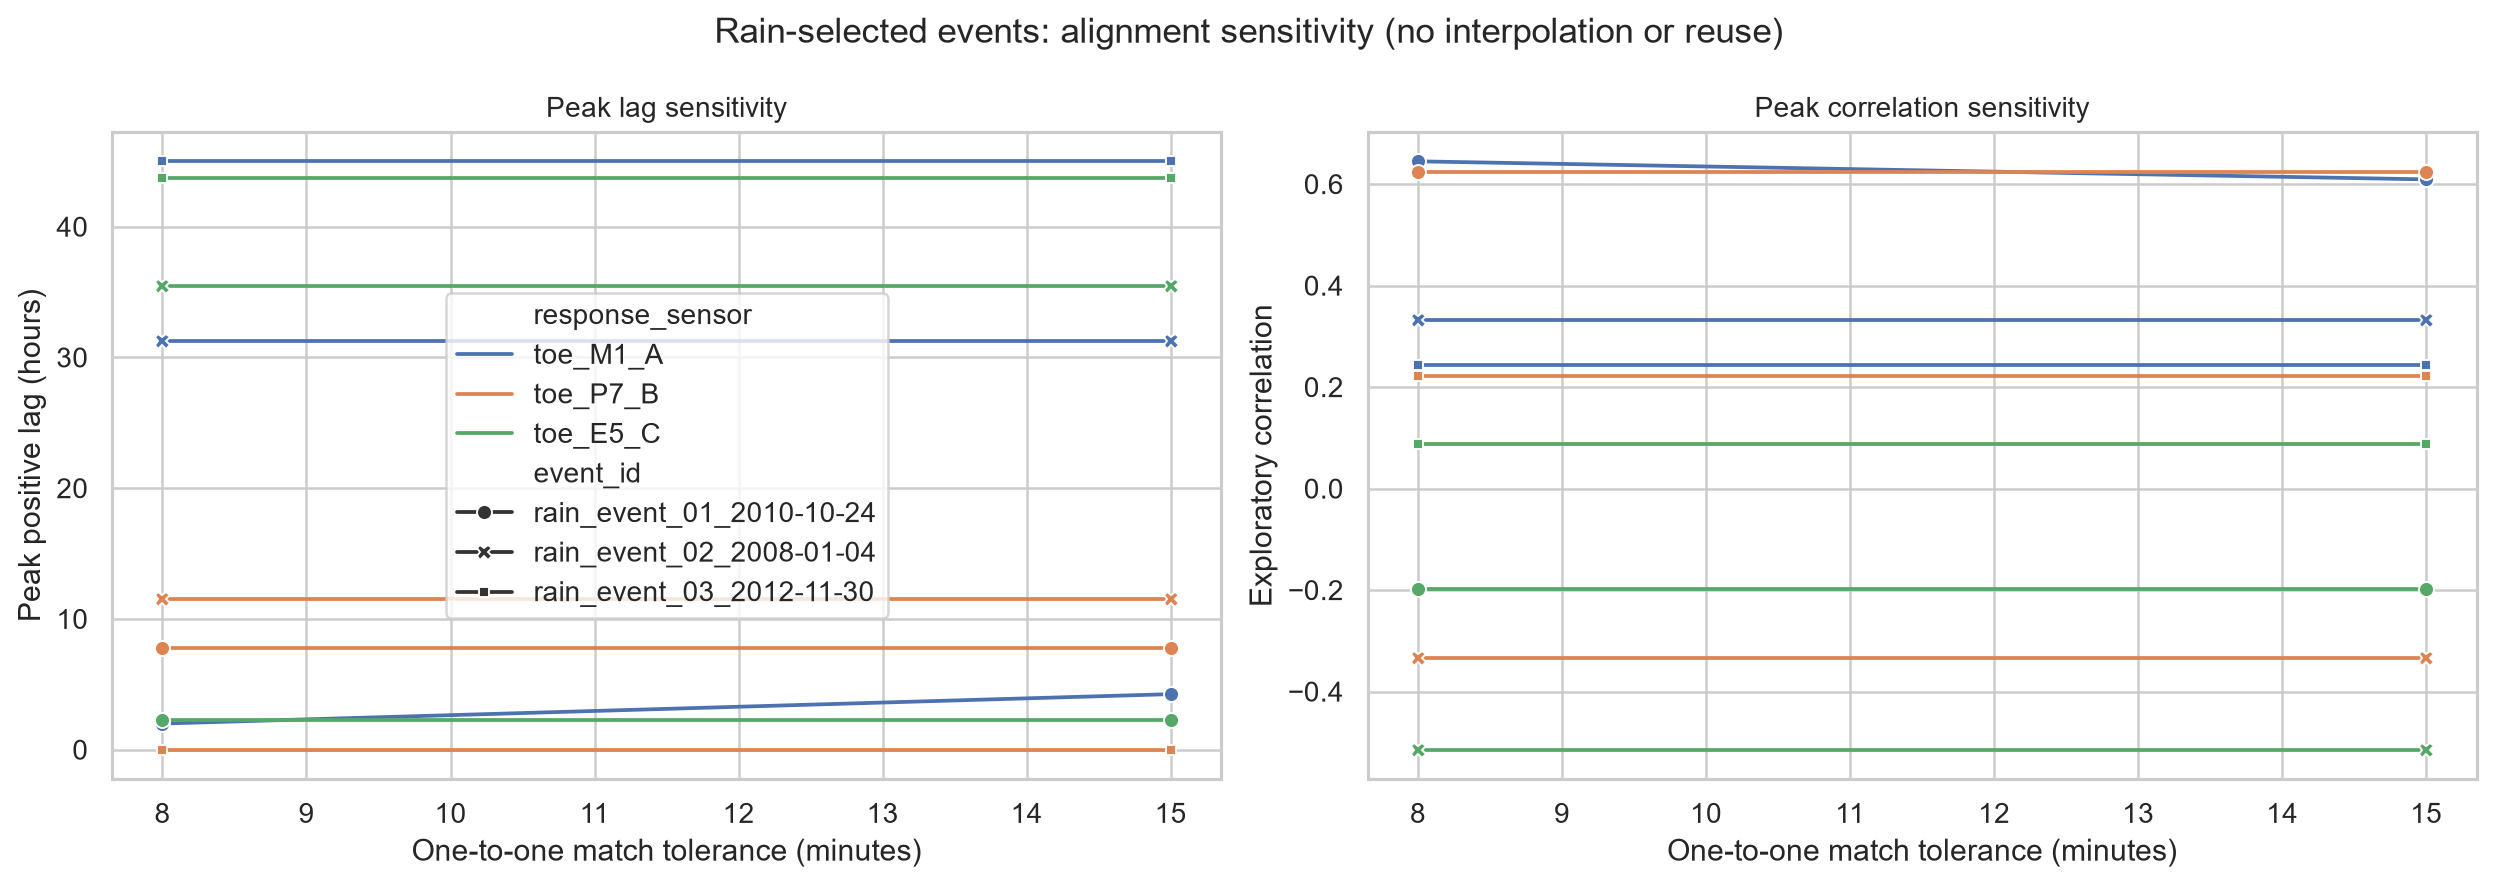

In [8]:
events = pd.read_csv(TABLES / 'event_selection.csv')
event_sensitivity = pd.read_csv(TABLES / 'event_alignment_sensitivity.csv')
display(events)
display(event_sensitivity)
display(Image(filename=str(FIGURES / '08_event_alignment_sensitivity.png')))

## Interpretation boundary

Observed results are the published values, masks, and aggregate diagnostics. Statistical interpretation concerns stationarity, dependence, and lag sensitivity. Engineering interpretation may compare the timing with the precipitation → wetting/pressure → movement hypothesis. Speculation about flow paths or mechanisms remains untested. Temporal association does not establish causation, and nothing here is an operational-warning or design result.

See `docs/CLEVELAND_CORRAL_PHASE3_EXPLORATORY_DYNAMICS.md` for the complete findings, limitations, and exact recommended Phase 4 objective.